## Importing packages


In [14]:
import os
import cv2
import glob
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torchvision import transforms, models
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split
from torchvision.models import ResNet18_Weights, resnet18
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### Constant


In [ ]:
# CONSTANT
BASE_DIR = 'Follow-Line-Combine-Dataset-path'
ADJUSTMENT_DATA_CSV = "adjustment_data.csv"
TRAIN_DATA_CSV = "train.csv"
PROCESSED_DIR = "PROCESSED_FILES_AND_IMAGE_OUTPUT_DIR"

# Paths
train_path = os.path.join(BASE_DIR, TRAIN_DATA_CSV)
adjustment_path = os.path.join(BASE_DIR, ADJUSTMENT_DATA_CSV)

#### Load datasets


In [16]:
# Load datasets
train_df = pd.read_csv(train_path)
adjustment_df = pd.read_csv(adjustment_path)

# combine adjustment and train dataset
combined_df = pd.concat([train_df, adjustment_df], ignore_index=True)

In [17]:
# DF Head
combined_df.head(3)

,image,v,w
0,images_part_03/simple_circuit-1754402572.38579...,4.000,1.42795
1,images_part_04/simple_circuit-1754402545.63768...,6.974,0.21409
2,images_part_02/nurburgring_circuit-1754401593....,4.000,-1.36925


In [18]:
# DF Describe
combined_df.describe()

# you can save the dataset if you want
combined_df.to_csv(os.path.join(PROCESSED_DIR,'data.csv'),index=False)

In [19]:
# DF Describe of linear velocity (v)
combined_df['v'].describe()

count    122564.000000
mean          4.567690
std           0.965617
min           0.000000
25%           4.000000
50%           4.000000
75%           4.906000
max           7.000000
Name: v, dtype: float64

In [20]:
# DF Describe of angular velocity (w)
combined_df['w'].describe()

count    122564.000000
mean         -0.005592
std           0.933623
min          -2.500000
25%          -0.489080
50%           0.001480
75%           0.464720
max           2.500000
Name: w, dtype: float64

## 1. Visualize indivisual circuits dataset


In [44]:
# Categorize angular velocity (w) into 5 categories
def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.05:
        return "right"
    elif w <= 0.05:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"

In [9]:
combined_df["w_category"] = combined_df["w"].apply(categorize_w)

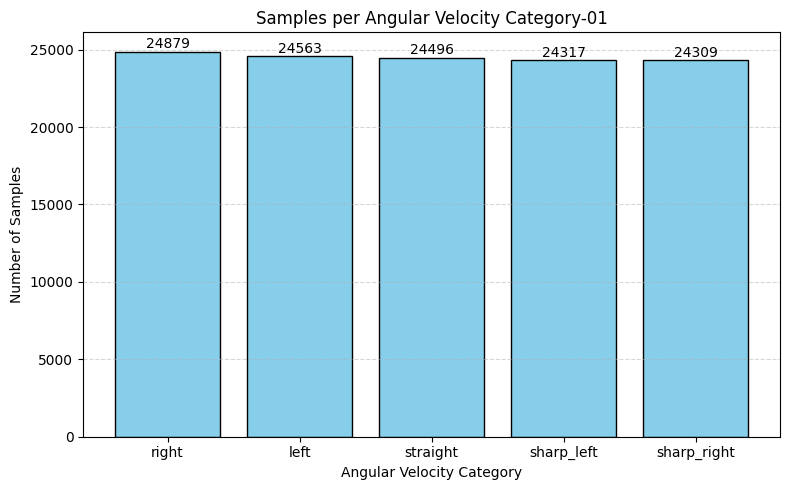

In [10]:
category_counts = combined_df['w_category'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title(f"Samples per Angular Velocity Category-01")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f"{BASE_DIR}-angular_velocity_category.png")
plt.show()

## 2. Dataset already balanced so we don't need to balanced it.


## 3. Image Processing


In [7]:
# Directory list
images_dir_list = [
    "images_part_01",
    "images_part_02",
    "images_part_03",
    "images_part_04",
    "images_part_05",
    "images_part_06",
    "adjustment_images",
]

In [16]:
IMG_HEIGHT = 240
error_images = 0
start_time = time.time()

for img_dir in images_dir_list:
    
    # GET THE FULL IMAGE INPUT PATH  
    image_path = os.path.join(BASE_DIR,img_dir)

    # CREATE FOLDER/CHECK according the current folder name
    os.makedirs(os.path.join(PROCESSED_DIR,img_dir),exist_ok=True)

    # GET LIST OF ALL THE `circuit` IMAGES
    image_list = glob.glob(os.path.join(image_path,'*.png'))

    # Transform to tensor
    to_tensor = transforms.ToTensor()  # Converts PIL to [C,H,W] FloatTensor in [0,1]
    to_pil = transforms.ToPILImage()   # For visualization or debug

    # LOOP THROUGH THE IAMGES
    for path in image_list:
        try:
            # Load image with PIL and convert to RGB
            img = Image.open(path).convert('RGB')
    
            # To tensor and move to GPU
            tensor = to_tensor(img).unsqueeze(0).cuda()  # Shape: [1, 3, H, W]
    
            # Crop last 240 rows
            cropped_tensor = tensor[:, :, -IMG_HEIGHT:, :]  # Shape: [1, 3, 240, W]
    
            # Move to CPU and convert to numpy image (H, W, C) in uint8
            cropped_img_np = (cropped_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    
            # Save using OpenCV
            filename = os.path.basename(path)
            # save to current dir folder in processed path
            save_path = os.path.join(PROCESSED_DIR,img_dir,filename)
            
                
            cv2.imwrite(save_path, cv2.cvtColor(cropped_img_np, cv2.COLOR_RGB2BGR))
    
        except Exception as e:
            print(f"Error processing {path}: {e}")
            error_images += 1

        
# end time
end_time = time.time()
elapsed = end_time - start_time

print(f"Failed to process {error_images} images.")
print(f"Elapsed time: {elapsed:.2f} seconds")

Failed to process 0 images.
Elapsed time: 436.48 seconds


## Train Model using NVIDIA PILOTNET


In [21]:
# ===================== DATASET =====================
class FollowLineDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Validate required columns
        expected_columns = ['image', 'v', 'w']
        if len(self.annotations.columns) < 3:
            raise ValueError(f"CSV must have at least 3 columns: {expected_columns}")
        
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()
    
        img_name = self.annotations.iloc[idx, 0]
        linear_velocity = float(self.annotations.iloc[idx, 1])
        angular_velocity = float(self.annotations.iloc[idx, 2])
    
        linear_velocity = round(linear_velocity, 3)
        angular_velocity = round(angular_velocity, 3)
    
        img_path = os.path.join(self.root_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(f"Image not found: {img_path}")
    
        if self.transform:
            image = self.transform(image)
    
        velocities = torch.tensor([linear_velocity, angular_velocity], dtype=torch.float32)
        return image, velocities

In [22]:
# ===================== RESNET MODEL =====================
class ResNetRegression(nn.Module):
    def __init__(self, base_model='resnet18', weights=None):
        super(ResNetRegression, self).__init__()
        
        # Load ResNet with weights
        if base_model == 'resnet18':
            self.resnet = models.resnet18(weights=weights)
        else:
            raise NotImplementedError("Only resnet18 supported for now")
        
        # Replace final fc for regression
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, 2)  # Output: [v, w]
        
    def forward(self, x):
        return self.resnet(x)


In [23]:
# ===================== CONFIG =====================
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
IMAGE_SHAPE = (3, 240, 640)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using DEVICE: {DEVICE}")

Using DEVICE: cuda


In [24]:
# ===================== TRANSFORMS =====================
transform = transforms.Compose([
    transforms.Resize((240, 640)),
    transforms.ToTensor(),
])

In [25]:
# ===================== LOAD DATA =====================
train_df, test_df = train_test_split(combined_df, test_size=0.2, random_state=42)
train_df.to_csv(f"{PROCESSED_DIR}/train.csv", index=False)
test_df.to_csv(f"{PROCESSED_DIR}/test.csv", index=False)

train_dataset = FollowLineDataset(os.path.join(PROCESSED_DIR, 'train.csv'), PROCESSED_DIR, transform=transform)
test_dataset = FollowLineDataset(os.path.join(PROCESSED_DIR, 'test.csv'), PROCESSED_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
# ===================== MODEL, LOSS, OPTIMIZER =====================
weights = ResNet18_Weights.DEFAULT  # or IMAGENET1K_V1 if you want legacy
model = resnet18(weights=weights)

model = ResNetRegression(base_model='resnet18', weights=ResNet18_Weights.DEFAULT).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [27]:

# ===================== TRAIN & TEST =====================
NUM_EPOCHS = 10
train_losses = []
test_losses = []

start_time = time.time()
for epoch in range(NUM_EPOCHS):
    # TRAIN
    model.train()
    total_train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # TEST
    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Test]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_test_loss += loss.item() * images.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

Epoch 1/10 [Test]: 100%|██████████████████████| 767/767 [01:40<00:00,  7.62it/s]


Epoch 1: Train Loss = 0.1333, Test Loss = 0.0364


Epoch 2/10 [Test]: 100%|██████████████████████| 767/767 [01:38<00:00,  7.80it/s]


Epoch 2: Train Loss = 0.0322, Test Loss = 0.0221


Epoch 3/10 [Test]: 100%|██████████████████████| 767/767 [01:37<00:00,  7.89it/s]


...

Epoch 8: Train Loss = 0.0089, Test Loss = 0.0130


Epoch 9/10 [Test]: 100%|██████████████████████| 767/767 [01:37<00:00,  7.85it/s]


Epoch 9: Train Loss = 0.0093, Test Loss = 0.0098


Epoch 10/10 [Test]: 100%|█████████████████████| 767/767 [01:37<00:00,  7.83it/s]

Epoch 10: Train Loss = 0.0078, Test Loss = 0.0094


### SAVE THE MODEL


In [ ]:
# ===================== SAVE MODEL =====================
dummy_input = torch.randn(1, 3, 240, 640).to(DEVICE)
onnx_path = f"{PROCESSED_DIR}/resnet_imitation_learning_model.onnx"

torch.onnx.export(model, dummy_input, onnx_path,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                  opset_version=11)

print(f"Model saved to {onnx_path}")

Model saved to /home/codezerro/Desktop/Processed_Combine_Dataset/resnet_imitation_learning_model.onnx


### PLOTTING TEST-TRAIN LOSS CURVE


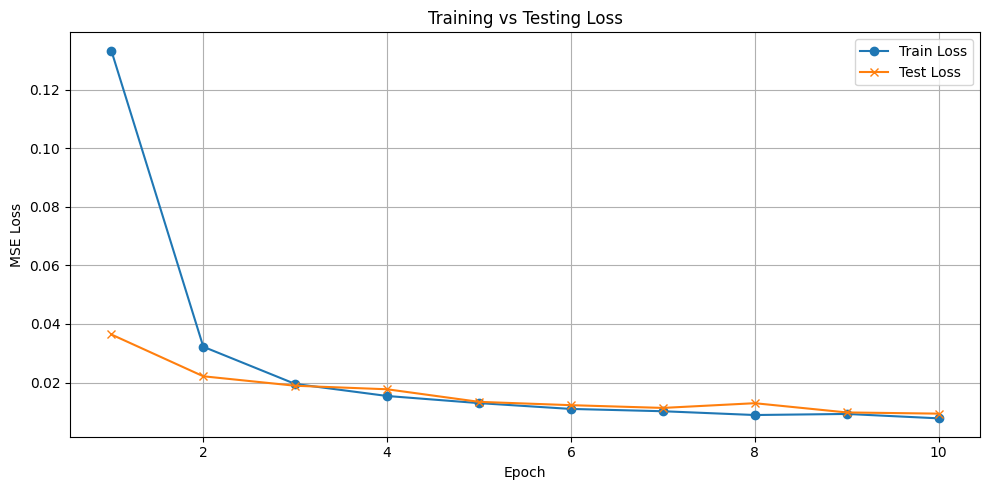

In [29]:
# ========================================== PLOTTING TEST-TRAIN LOSS CURVE ==========================================
# Plotting loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses[:NUM_EPOCHS], label='Train Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses[:NUM_EPOCHS], label=f"Test Loss", marker='x')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Testing Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/loss_curve.png")
plt.show() 


### Evaluation Matrix


In [30]:
# ========================================== EVALUATION MATRICES ==========================================
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        all_preds.append(outputs.cpu())
        all_targets.append(targets.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

mse_total = mean_squared_error(all_targets, all_preds)
mae_total = mean_absolute_error(all_targets, all_preds)
r2_total = r2_score(all_targets, all_preds)

mse_v = mean_squared_error(all_targets[:, 0], all_preds[:, 0])
mae_v = mean_absolute_error(all_targets[:, 0], all_preds[:, 0])
r2_v = r2_score(all_targets[:, 0], all_preds[:, 0])

mse_w = mean_squared_error(all_targets[:, 1], all_preds[:, 1])
mae_w = mean_absolute_error(all_targets[:, 1], all_preds[:, 1])
r2_w = r2_score(all_targets[:, 1], all_preds[:, 1])


# save evaluation matrics results
with open(f"{PROCESSED_DIR}/evaluation_matrics.txt", "w") as f:
    f.write(f"--- Evaluation Metrics ---\n")
    f.write(f"Combined - MSE: {mse_total:.4f}, MAE: {mae_total:.4f}, R2: {r2_total:.4f}\n")
    f.write(f"Linear Velocity (v) - MSE: {mse_v:.4f}, MAE: {mae_v:.4f}, R2: {r2_v:.4f}\n")
    f.write(f"Angular Velocity (w) - MSE: {mse_w:.4f}, MAE: {mae_w:.4f}, R2: {r2_w:.4f}\n")
    f.write(f"\n\n\n")

Evaluating: 100%|█████████████████████████████| 767/767 [01:42<00:00,  7.46it/s]
